# Cross-Domain Traffic Classification — RF and XGBoost with Flow-Level Features

Trains on non-VPN flows, evaluates on VPN-encapsulated flows. Input: 23 flow-level statistical features (packet counts, byte counts, duration, inter-arrival time statistics). Feature alignment maps VPN outer-flow column names to the canonical non-VPN schema before training. Confidence intervals from bootstrap resampling (B=1000) on the VPN test set.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report,
                              confusion_matrix)
from IPython.display import display

try:
    import xgboost as xgb
    print(f'XGBoost version: {xgb.__version__}')
    XGB_AVAILABLE = True
except ImportError:
    print('WARNING: xgboost not installed. XGBoost cells will be skipped.')
    XGB_AVAILABLE = False

try:
    import shap
    print(f'SHAP version: {shap.__version__}')
    SHAP_AVAILABLE = True
except ImportError:
    print('WARNING: shap not installed. SHAP cells will be skipped.')
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports complete.')


XGBoost version: 3.2.0
SHAP version: 0.51.0
Imports complete.


## Feature Alignment Schema

In [2]:
# ── Semantic Feature Mapping ────────────────────────────────────────────────────
# non-VPN canonical names  →  VPN equivalent column names
FEATURE_MAP = {
    'bidirectional_packets':       'matched_packets',
    'bidirectional_bytes':         'outer_bytes',
    'bidirectional_mean_ps':       'mean_outer_pkt_size',
    'bidirectional_stddev_ps':     'std_outer_pkt_size',
    'bidirectional_min_piat_ms':   'outer_min_piat_ms',
    'bidirectional_mean_piat_ms':  'outer_mean_piat_ms',
    'bidirectional_stddev_piat_ms':'outer_stddev_piat_ms',
    'bidirectional_max_piat_ms':   'outer_max_piat_ms',
    'bidirectional_duration_ms':   'outer_capture_duration_ms',
    'bidirectional_first_seen_ms': 'outer_first_matched_time_ms',
    'bidirectional_last_seen_ms':  'outer_last_matched_time_ms',
    'dst2src_bytes':               'outer_bytes_in',
    'src2dst_bytes':               'outer_bytes_out',
    'dst2src_min_piat_ms':         'outer_min_piat_ms_in',
    'dst2src_mean_piat_ms':        'outer_mean_piat_ms_in',
    'dst2src_stddev_piat_ms':      'outer_stddev_piat_ms_in',
    'dst2src_max_piat_ms':         'outer_max_piat_ms_in',
    'src2dst_min_piat_ms':         'outer_min_piat_ms_out',
    'src2dst_mean_piat_ms':        'outer_mean_piat_ms_out',
    'src2dst_stddev_piat_ms':      'outer_stddev_piat_ms_out',
    'src2dst_max_piat_ms':         'outer_max_piat_ms_out',
    'bidirectional_packet_rate':   'outer_packet_rate',
    'bidirectional_byte_rate':     'outer_byte_rate',
}

CANONICAL_FEATURES = list(FEATURE_MAP.keys())  # 23 features, train on these

print(f'Canonical feature set ({len(CANONICAL_FEATURES)} features):')
for i, f in enumerate(CANONICAL_FEATURES):
    print(f'  [{i+1:02d}] {f:35s}  →  {FEATURE_MAP[f]}')

# ── Feature extraction functions ───────────────────────────────────────────────

def get_nonvpn_features(df):
    """Extract canonical features from non-VPN DataFrame."""
    available = [c for c in CANONICAL_FEATURES if c in df.columns]
    missing   = [c for c in CANONICAL_FEATURES if c not in df.columns]
    if missing:
        print(f'  WARNING: {len(missing)} non-VPN features not found: {missing[:5]}...')
    out = df[available].copy()
    for c in missing:
        out[c] = 0.0
    return out[CANONICAL_FEATURES].fillna(0.0)


def get_vpn_features(df):
    """Extract features from VPN DataFrame and rename to canonical names."""
    inv_map = {v: k for k, v in FEATURE_MAP.items()}
    vpn_cols_needed = list(FEATURE_MAP.values())
    available_vpn   = [c for c in vpn_cols_needed if c in df.columns]
    missing_vpn     = [c for c in vpn_cols_needed if c not in df.columns]
    if missing_vpn:
        print(f'  WARNING: {len(missing_vpn)} VPN features not found: {missing_vpn[:5]}...')
    out = df[available_vpn].rename(columns=inv_map).copy()
    for c in CANONICAL_FEATURES:
        if c not in out.columns:
            out[c] = 0.0
    return out[CANONICAL_FEATURES].fillna(0.0)


# ── Shared metric / plotting helpers ──────────────────────────────────────────

def compute_metrics(y_true, y_pred):
    return {
        'accuracy':     accuracy_score(y_true, y_pred),
        'bal_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1':     f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'weighted_f1':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def plot_blue_cm(cm, labels, title, save_path=None):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.75), max(8, n * 0.65)))
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.4, linecolor='#d0d0d0', ax=ax,
                cbar_kws={'shrink': 0.75}, annot_kws={'size': 8})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def show_metrics_table(metrics_dict, title='Metrics'):
    df = pd.DataFrame([metrics_dict]).round(4)
    df.index = [title]
    display(df.style.background_gradient(cmap='Blues', axis=1))
    return df


# ── Bootstrap CI (replaces k-fold for cross-domain evaluation) ─────────────────
def run_bootstrap_ci(y_true, y_pred, B=1000, seed=42, tag='', save_dir=None):
    """Bootstrap confidence intervals on the VPN test set.

    Strategy: train once on all non-VPN data, then resample VPN predictions
    B=1000 times with replacement.  Reports 95% CI [2.5th – 97.5th percentile].
    This measures test-set uncertainty rather than training variance.
    """
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    boot = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        boot.append(compute_metrics(y_true[idx], y_pred[idx]))

    df_boot = pd.DataFrame(boot)
    lo = df_boot.quantile(0.025)
    hi = df_boot.quantile(0.975)
    mn = df_boot.mean()

    ci_rows = []
    print(f'\n{"="*60}')
    print(f'Bootstrap CI (B={B}): {tag}')
    print(f'{"="*60}')
    for metric in ['accuracy', 'bal_accuracy', 'macro_f1', 'weighted_f1']:
        print(f'  {metric:20s}: {mn[metric]:.4f}  95% CI [{lo[metric]:.4f}, {hi[metric]:.4f}]')
        ci_rows.append({'metric': metric,
                        'mean': mn[metric], 'ci_lo': lo[metric], 'ci_hi': hi[metric]})

    ci_df = pd.DataFrame(ci_rows).set_index('metric')

    if save_dir:
        ci_df.to_csv(os.path.join(save_dir, f'{tag}_bootstrap_ci.csv'))
        df_boot.to_csv(os.path.join(save_dir, f'{tag}_bootstrap_dist.csv'), index=False)

    return ci_df, df_boot


def plot_bootstrap_dist(df_boot, metric='macro_f1', tag='', save_dir=None):
    """Plot bootstrap distribution histogram with 95% CI shading."""
    vals = df_boot[metric].values
    lo, hi = np.percentile(vals, [2.5, 97.5])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(lo, color='red',    linestyle='--', linewidth=1.5, label=f'2.5th pct = {lo:.4f}')
    ax.axvline(hi, color='red',    linestyle='--', linewidth=1.5, label=f'97.5th pct = {hi:.4f}')
    ax.axvline(vals.mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean = {vals.mean():.4f}')
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel('Bootstrap Frequency', fontsize=11)
    ax.set_title(f'Bootstrap Distribution — {tag}\n{metric} (B={len(vals)})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, f'{tag}_bootstrap_dist.png'), dpi=150, bbox_inches='tight')
    plt.show()


print('\nAll helpers defined (bootstrap CI replaces k-fold for cross-domain).')


Canonical feature set (23 features):
  [01] bidirectional_packets                →  matched_packets
  [02] bidirectional_bytes                  →  outer_bytes
  [03] bidirectional_mean_ps                →  mean_outer_pkt_size
  [04] bidirectional_stddev_ps              →  std_outer_pkt_size
  [05] bidirectional_min_piat_ms            →  outer_min_piat_ms
  [06] bidirectional_mean_piat_ms           →  outer_mean_piat_ms
  [07] bidirectional_stddev_piat_ms         →  outer_stddev_piat_ms
  [08] bidirectional_max_piat_ms            →  outer_max_piat_ms
  [09] bidirectional_duration_ms            →  outer_capture_duration_ms
  [10] bidirectional_first_seen_ms          →  outer_first_matched_time_ms
  [11] bidirectional_last_seen_ms           →  outer_last_matched_time_ms
  [12] dst2src_bytes                        →  outer_bytes_in
  [13] src2dst_bytes                        →  outer_bytes_out
  [14] dst2src_min_piat_ms                  →  outer_min_piat_ms_in
  [15] dst2src_mean_piat_ms  

## Configuration

In [10]:
# ── Config + output dirs ───────────────────────────────────────────────────────
SEED = 42

VPN_FILE    = r'.\dataset\mapped_f\vpn_all_filtered_min200.csv'
NONVPN_FILE = r'.\dataset\mapped_f\nonvpn_all_filtered_min200.csv'
TARGET_COL  = 'application_category_name'

OUT_BASE = r'.\results_03_CrossDomain_RF_XGB_FlowFeatures'
OUT_RF   = os.path.join(OUT_BASE, 'RF')
OUT_XGB  = os.path.join(OUT_BASE, 'XGB')
os.makedirs(OUT_RF,  exist_ok=True)
os.makedirs(OUT_XGB, exist_ok=True)
print('Output directories created.')

# ── Load data ──────────────────────────────────────────────────────────────────
print('Loading VPN data ...')
df_vpn = pd.read_csv(VPN_FILE)
print(f'  VPN shape: {df_vpn.shape}')

print('Loading non-VPN data ...')
df_nonvpn = pd.read_csv(NONVPN_FILE)
print(f'  non-VPN shape: {df_nonvpn.shape}')

# ── Extract properly aligned features ─────────────────────────────────────────
print('\nExtracting non-VPN features (canonical names) ...')
X_nonvpn_df = get_nonvpn_features(df_nonvpn)
print(f'  non-VPN feature matrix: {X_nonvpn_df.shape}')

print('Extracting VPN features (remapped to canonical names) ...')
X_vpn_df = get_vpn_features(df_vpn)
print(f'  VPN feature matrix: {X_vpn_df.shape}')

X_nonvpn = X_nonvpn_df.values.astype(np.float32)
X_vpn    = X_vpn_df.values.astype(np.float32)

# Label encoding
le = LabelEncoder()
all_labels = pd.concat([df_nonvpn[TARGET_COL], df_vpn[TARGET_COL]]).unique()
le.fit(all_labels)
y_nonvpn = le.transform(df_nonvpn[TARGET_COL])
y_vpn    = le.transform(df_vpn[TARGET_COL])
NUM_CLASSES = len(le.classes_)

print(f'\nClasses ({NUM_CLASSES}): {list(le.classes_)}')
print(f'\nAligned feature names used for training:')
for i, name in enumerate(CANONICAL_FEATURES):
    print(f'  [{i+1:02d}] {name}')


Output directories created.
Loading VPN data ...
  VPN shape: (226314, 29)
Loading non-VPN data ...
  non-VPN shape: (226314, 29)

Extracting non-VPN features (canonical names) ...
  non-VPN feature matrix: (226314, 23)
Extracting VPN features (remapped to canonical names) ...
  VPN feature matrix: (226314, 23)

Classes (14): ['Chat', 'Cloud', 'Collaborative', 'ConnCheck', 'Database', 'Download', 'Email', 'Network', 'SocialNetwork', 'SoftwareUpdate', 'System', 'Unspecified', 'VoIP', 'Web']

Aligned feature names used for training:
  [01] bidirectional_packets
  [02] bidirectional_bytes
  [03] bidirectional_mean_ps
  [04] bidirectional_stddev_ps
  [05] bidirectional_min_piat_ms
  [06] bidirectional_mean_piat_ms
  [07] bidirectional_stddev_piat_ms
  [08] bidirectional_max_piat_ms
  [09] bidirectional_duration_ms
  [10] bidirectional_first_seen_ms
  [11] bidirectional_last_seen_ms
  [12] dst2src_bytes
  [13] src2dst_bytes
  [14] dst2src_min_piat_ms
  [15] dst2src_mean_piat_ms
  [16] dst2s

## Random Forest

=== RANDOM FOREST (Traditional Flow Features — Aligned) ===

Training RF on all non-VPN data ...
RF trained.

Final RF Metrics:


,accuracy,bal_accuracy,macro_f1,weighted_f1
Final RF — Aligned Traditional Features (non-VPN → VPN),0.939500,0.629700,0.708900,0.927200


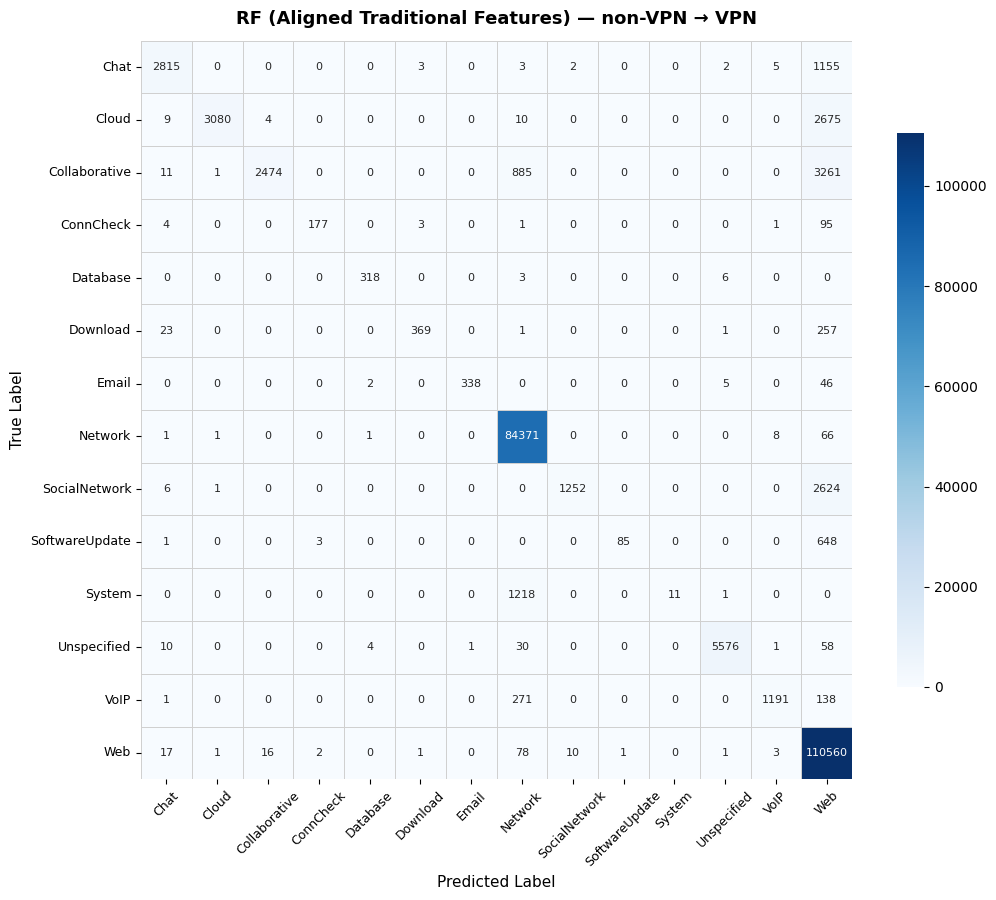


Bootstrap CI (B=1000): RF_FlowF
  accuracy            : 0.9395  95% CI [0.9385, 0.9405]
  bal_accuracy        : 0.6298  95% CI [0.6238, 0.6356]
  macro_f1            : 0.7089  95% CI [0.7033, 0.7142]
  weighted_f1         : 0.9271  95% CI [0.9259, 0.9285]


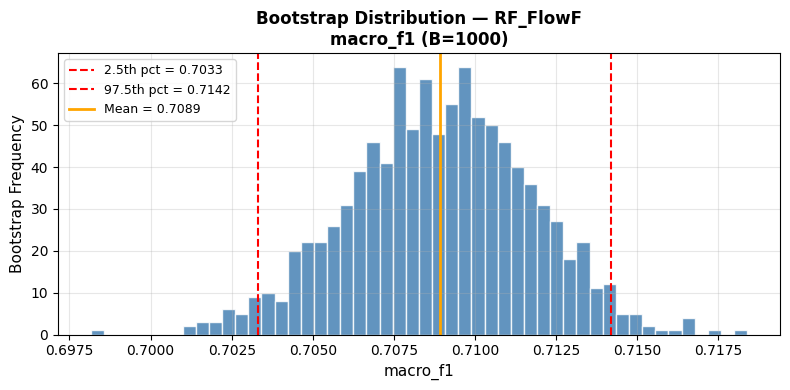

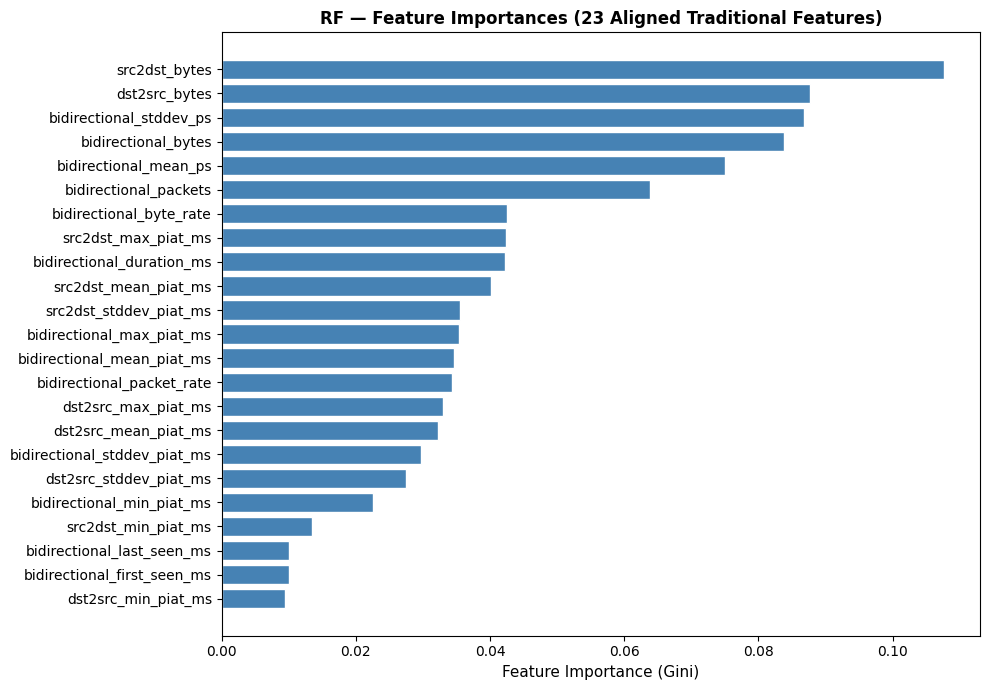

RF complete.


In [4]:
# ── Random Forest ──────────────────────────────────────────────────────────────
print('=== RANDOM FOREST (Traditional Flow Features — Aligned) ===')

# Train final RF on all non-VPN data
print('\nTraining RF on all non-VPN data ...')
final_rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, n_jobs=-1,
    class_weight='balanced', random_state=SEED)
final_rf.fit(X_nonvpn, y_nonvpn)
print('RF trained.')

y_pred_rf = final_rf.predict(X_vpn)
rf_metrics = compute_metrics(y_vpn, y_pred_rf)
print('\nFinal RF Metrics:')
show_metrics_table(rf_metrics, title='Final RF — Aligned Traditional Features (non-VPN → VPN)')

# Blue confusion matrix
cm_rf = confusion_matrix(y_vpn, y_pred_rf)
plot_blue_cm(cm_rf, list(le.classes_),
             title='RF (Aligned Traditional Features) — non-VPN → VPN',
             save_path=os.path.join(OUT_RF, 'rf_flowf_confusion_matrix.png'))

# Bootstrap CI on VPN test set
rf_ci_df, rf_boot_df = run_bootstrap_ci(
    y_vpn, y_pred_rf, B=1000, seed=SEED, tag='RF_FlowF', save_dir=OUT_RF)
plot_bootstrap_dist(rf_boot_df, metric='macro_f1', tag='RF_FlowF', save_dir=OUT_RF)

# Save classification report
report_rf = classification_report(y_vpn, y_pred_rf, target_names=list(le.classes_), zero_division=0)
with open(os.path.join(OUT_RF, 'rf_flowf_report.txt'), 'w') as f:
    f.write(report_rf)
with open(os.path.join(OUT_RF, 'rf_flowf_final_metrics.json'), 'w') as f:
    json.dump(rf_metrics, f, indent=2)

# Feature importance
fi = final_rf.feature_importances_
fi_order = np.argsort(fi)[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([CANONICAL_FEATURES[i] for i in fi_order[::-1]],
        fi[fi_order[::-1]], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('RF — Feature Importances (23 Aligned Traditional Features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_RF, 'rf_flowf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('RF complete.')


## XGBoost

=== XGBOOST (Traditional Flow Features — Aligned) ===

Training final XGBoost on all non-VPN data ...
Final XGBoost trained.

Final XGBoost Metrics:


,accuracy,bal_accuracy,macro_f1,weighted_f1
Final XGBoost — Aligned Traditional Features (non-VPN → VPN),0.944500,0.916700,0.861300,0.948300


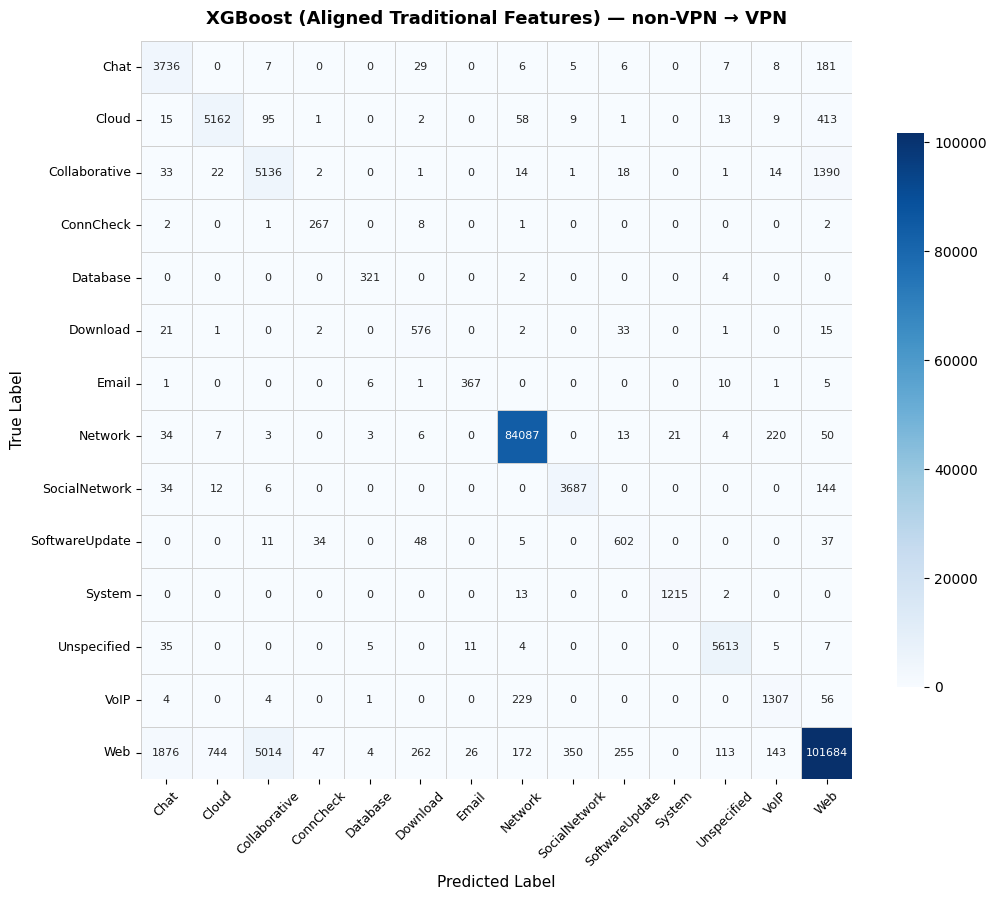


Bootstrap CI (B=1000): XGB_FlowF
  accuracy            : 0.9445  95% CI [0.9436, 0.9455]
  bal_accuracy        : 0.9167  95% CI [0.9124, 0.9209]
  macro_f1            : 0.8614  95% CI [0.8570, 0.8657]
  weighted_f1         : 0.9483  95% CI [0.9474, 0.9491]


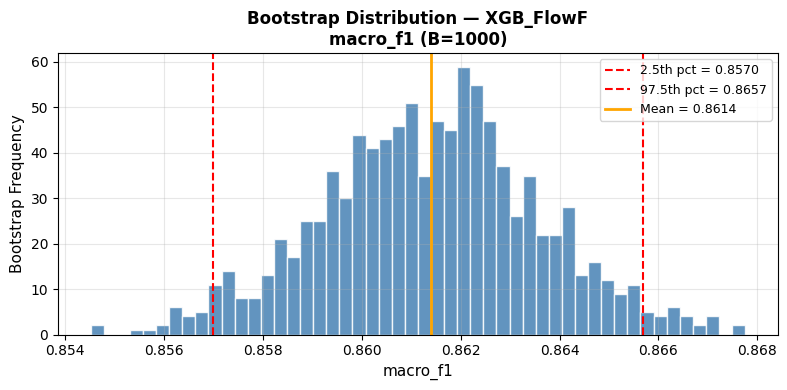

XGBoost complete.


In [5]:
# ── XGBoost ────────────────────────────────────────────────────────────────────
if not XGB_AVAILABLE:
    print('XGBoost not available — skipping.')
else:
    print('=== XGBOOST (Traditional Flow Features — Aligned) ===')

    # Sample weights for class balance (XGBoost doesn't accept class_weight='balanced')
    from sklearn.utils.class_weight import compute_sample_weight
    sw_xgb = compute_sample_weight('balanced', y_nonvpn)

    # Train final XGBoost on all non-VPN data
    print('\nTraining final XGBoost on all non-VPN data ...')
    final_xgb = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        n_jobs=-1, random_state=SEED, verbosity=0)
    final_xgb.fit(X_nonvpn, y_nonvpn, sample_weight=sw_xgb)
    print('Final XGBoost trained.')

    y_pred_xgb = final_xgb.predict(X_vpn)
    xgb_metrics = compute_metrics(y_vpn, y_pred_xgb)
    print('\nFinal XGBoost Metrics:')
    show_metrics_table(xgb_metrics, title='Final XGBoost — Aligned Traditional Features (non-VPN → VPN)')

    # Blue confusion matrix
    cm_xgb = confusion_matrix(y_vpn, y_pred_xgb)
    plot_blue_cm(cm_xgb, list(le.classes_),
                 title='XGBoost (Aligned Traditional Features) — non-VPN → VPN',
                 save_path=os.path.join(OUT_XGB, 'xgb_flowf_confusion_matrix.png'))

    # Bootstrap CI on VPN test set
    xgb_ci_df, xgb_boot_df = run_bootstrap_ci(
        y_vpn, y_pred_xgb, B=1000, seed=SEED, tag='XGB_FlowF', save_dir=OUT_XGB)
    plot_bootstrap_dist(xgb_boot_df, metric='macro_f1', tag='XGB_FlowF', save_dir=OUT_XGB)

    # Save
    report_xgb = classification_report(y_vpn, y_pred_xgb,
                                       target_names=list(le.classes_), zero_division=0)
    with open(os.path.join(OUT_XGB, 'xgb_flowf_report.txt'), 'w') as f:
        f.write(report_xgb)
    with open(os.path.join(OUT_XGB, 'xgb_flowf_final_metrics.json'), 'w') as f:
        json.dump(xgb_metrics, f, indent=2)
    print('XGBoost complete.')


## SHAP Analysis

Computing SHAP values on XGBoost ...


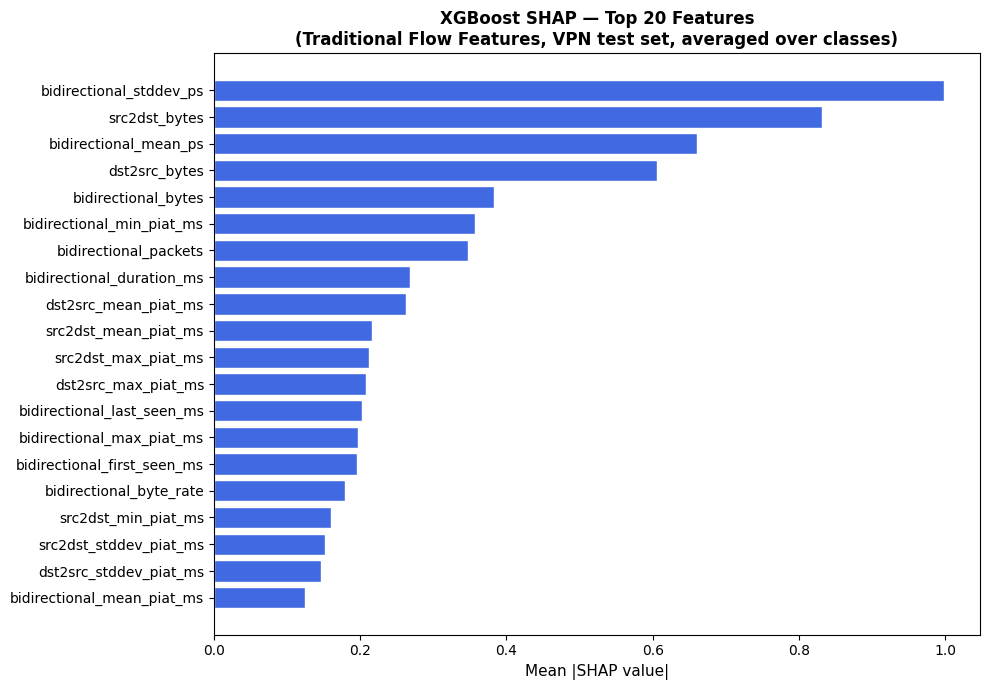

SHAP analysis complete.


In [6]:
# ── SHAP on XGBoost ────────────────────────────────────────────────────────────
if not XGB_AVAILABLE:
    print('XGBoost not available — skipping SHAP.')
elif not SHAP_AVAILABLE:
    print('SHAP not available — skipping SHAP analysis.')
else:
    print('Computing SHAP values on XGBoost ...')

    MAX_SHAP_SAMPLES = 2000
    if len(X_vpn) > MAX_SHAP_SAMPLES:
        rng_idx = np.random.choice(len(X_vpn), MAX_SHAP_SAMPLES, replace=False)
        X_shap  = X_vpn[rng_idx]
    else:
        X_shap = X_vpn

    explainer   = shap.TreeExplainer(final_xgb)
    shap_values = explainer.shap_values(X_shap)

    # For multi-class: shap_values is a list of arrays
    _sv = np.array(shap_values)
    _nf = X_shap.shape[1]
    if _sv.ndim == 3:
        _fa = next((a for a in range(3) if _sv.shape[a] == _nf), None)
        if _fa is not None:
            _oa = tuple(a for a in range(3) if a != _fa)
            mean_abs_shap = np.abs(_sv).mean(axis=_oa)
        else:
            mean_abs_shap = np.abs(_sv).mean(axis=(0, 1))
    elif isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(_sv).mean(axis=0)
    mean_abs_shap = np.array(mean_abs_shap).flatten()

    shap_order = np.argsort(mean_abs_shap)[::-1][:20]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh([CANONICAL_FEATURES[int(i)] for i in shap_order[::-1]],
            mean_abs_shap[shap_order[::-1]],
            color='royalblue', edgecolor='white')
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title('XGBoost SHAP — Top 20 Features\n(Traditional Flow Features, VPN test set, averaged over classes)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_XGB, 'xgb_flowf_shap_top20.png'), dpi=150, bbox_inches='tight')
    plt.show()

    shap_df = pd.DataFrame({
        'canonical_feature':  CANONICAL_FEATURES,
        'vpn_equivalent':     [FEATURE_MAP[f] for f in CANONICAL_FEATURES],
        'mean_abs_shap':      mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    shap_df.to_csv(os.path.join(OUT_XGB, 'xgb_flowf_shap_importances.csv'), index=False)
    print('SHAP analysis complete.')

## Save Models

In [7]:
import joblib
# ── Save trained models ─────────────────────────────────────────────────────
# RF
joblib.dump(final_rf, os.path.join(OUT_RF, 'rf_final_model.pkl'))
print(f'RF model saved  → {os.path.join(OUT_RF, "rf_final_model.pkl")}')

# XGBoost (native JSON format)
if XGB_AVAILABLE:
    final_xgb.save_model(os.path.join(OUT_XGB, 'xgb_final_model.json'))
    print(f'XGB model saved → {os.path.join(OUT_XGB, "xgb_final_model.json")}')

# MLP

# Label encoder + canonical feature list (needed to decode predictions and align features)
joblib.dump(le, os.path.join(OUT_RF, 'label_encoder.pkl'))
print(f'LabelEncoder saved → {os.path.join(OUT_RF, "label_encoder.pkl")}')

import json as _json
with open(os.path.join(OUT_RF, 'canonical_features.json'), 'w') as f:
    _json.dump({'CANONICAL_FEATURES': CANONICAL_FEATURES, 'FEATURE_MAP': FEATURE_MAP}, f, indent=2)
print(f'Canonical feature schema saved → {os.path.join(OUT_RF, "canonical_features.json")}')
print('All old-features cross-domain models saved.')


RF model saved  → .\results_03_CrossDomain_RF_XGB_FlowFeatures\RF\rf_final_model.pkl
XGB model saved → .\results_03_CrossDomain_RF_XGB_FlowFeatures\XGB\xgb_final_model.json
LabelEncoder saved → .\results_03_CrossDomain_RF_XGB_FlowFeatures\RF\label_encoder.pkl
Canonical feature schema saved → .\results_03_CrossDomain_RF_XGB_FlowFeatures\RF\canonical_features.json
All old-features cross-domain models saved.


## Save Predictions

In [8]:
# ── Save predictions + probabilities for ROC / PR curve analysis ───────────────
# Format: y_true (int), y_pred (int), y_true_name, y_pred_name, prob_<ClassName> x n_classes

def save_pred_csv(y_true, y_pred, proba, le, prefix, out_dir):
    """Save ground-truth, predictions, and per-class probabilities to CSV."""
    df = pd.DataFrame({
        'y_true':      y_true,
        'y_pred':      y_pred,
        'y_true_name': le.inverse_transform(y_true),
        'y_pred_name': le.inverse_transform(y_pred),
    })
    for j, cls in enumerate(le.classes_):
        df[f'prob_{cls}'] = proba[:, j]
    path = os.path.join(out_dir, f'{prefix}_predictions.csv')
    df.to_csv(path, index=False)
    print(f'  Saved: {prefix}_predictions.csv  ({len(df):,} rows, {len(le.classes_)} class proba cols)')
    return df

print('Saving predictions + probabilities ...')

# RF
proba_rf = final_rf.predict_proba(X_vpn)
save_pred_csv(y_vpn, y_pred_rf, proba_rf, le, 'rf_flowf', OUT_RF)

# XGBoost
if XGB_AVAILABLE:
    proba_xgb = final_xgb.predict_proba(X_vpn)
    save_pred_csv(y_vpn, y_pred_xgb, proba_xgb, le, 'xgb_flowf', OUT_XGB)


# Class name mapping
with open(os.path.join(OUT_BASE, 'FlowF_class_names.json'), 'w') as f:
    json.dump({str(i): cls for i, cls in enumerate(le.classes_)}, f, indent=2)
print('Class name mapping saved → FlowF_class_names.json')


Saving predictions + probabilities ...
  Saved: rf_flowf_predictions.csv  (226,314 rows, 14 class proba cols)
  Saved: xgb_flowf_predictions.csv  (226,314 rows, 14 class proba cols)
Class name mapping saved → FlowF_class_names.json


## Model Comparison

=== COMPARISON TABLE: FIXED ALIGNMENT vs ORIGINAL BROKEN BASELINE ===

Full comparison table (bootstrap 95% CI on VPN test set):


,Final Acc,Final Bal Acc,Final Macro F1,Final Weighted F1,Boot Macro F1,Boot F1 CI Lo,Boot F1 CI Hi
Model,,,,,,,
Random Forest (fixed),0.939500,0.629700,0.708900,0.927200,0.708900,0.703300,0.714200
XGBoost (fixed),0.944500,0.916700,0.861300,0.948300,0.861400,0.857000,0.865700
BROKEN Baseline (NaN merge bug),0.489000,0.071000,nan,nan,nan,nan,nan



Saved: C:\Users\Yasameen\enhanced_v2\results_03_CrossDomain_RF_XGB_FlowFeatures/FlowF_model_comparison.csv


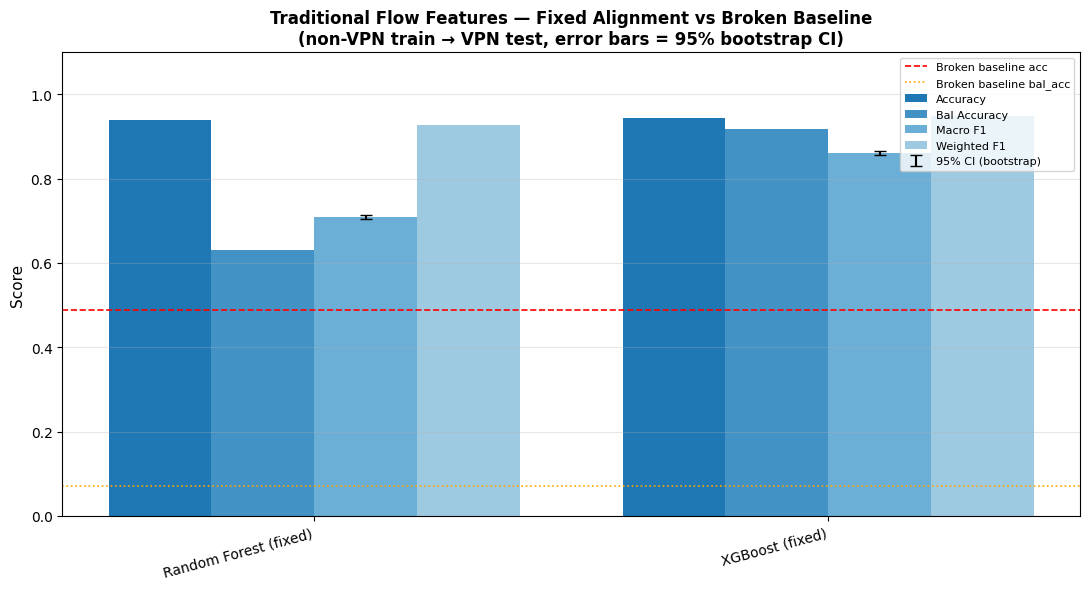


=== IMPROVEMENT OVER BROKEN BASELINE ===
Random Forest (fixed)                Acc ++0.4505  Bal Acc ++0.5587  Macro F1=0.7089 95%CI [0.7033, 0.7142]
XGBoost (fixed)                      Acc ++0.4555  Bal Acc ++0.8457  Macro F1=0.8613 95%CI [0.8570, 0.8657]


In [9]:
# ── Comparison Table: Fixed Alignment vs Broken Baseline ───────────────────────
print('=== COMPARISON TABLE: FIXED ALIGNMENT vs ORIGINAL BROKEN BASELINE ===')

# Broken baseline (original NaN-column merge bug)
BROKEN_BASELINE = {
    'Model':            'BROKEN Baseline (NaN merge bug)',
    'Final Acc':        0.489,
    'Final Bal Acc':    0.071,
    'Final Macro F1':   float('nan'),
    'Final Weighted F1':float('nan'),
    'Boot Macro F1':    float('nan'),
    'Boot F1 CI Lo':    float('nan'),
    'Boot F1 CI Hi':    float('nan'),
    'Note': 'Original code — VPN test features all NaN due to column name mismatch'
}

def _ci_row(ci_df, metric):
    """Helper: extract CI bounds from a bootstrap ci_df."""
    try:
        return ci_df.loc[metric, 'ci_lo'], ci_df.loc[metric, 'ci_hi']
    except Exception:
        return float('nan'), float('nan')

rows = []

# RF row
rf_lo, rf_hi = _ci_row(rf_ci_df, 'macro_f1')
rows.append({
    'Model':            'Random Forest (fixed)',
    'Final Acc':        rf_metrics['accuracy'],
    'Final Bal Acc':    rf_metrics['bal_accuracy'],
    'Final Macro F1':   rf_metrics['macro_f1'],
    'Final Weighted F1':rf_metrics['weighted_f1'],
    'Boot Macro F1':    rf_ci_df.loc['macro_f1', 'mean'],
    'Boot F1 CI Lo':    rf_lo,
    'Boot F1 CI Hi':    rf_hi,
    'Note': f'n_estimators=500, balanced, {len(CANONICAL_FEATURES)} aligned features'
})

# XGBoost row
if XGB_AVAILABLE:
    xgb_lo, xgb_hi = _ci_row(xgb_ci_df, 'macro_f1')
    rows.append({
        'Model':            'XGBoost (fixed)',
        'Final Acc':        xgb_metrics['accuracy'],
        'Final Bal Acc':    xgb_metrics['bal_accuracy'],
        'Final Macro F1':   xgb_metrics['macro_f1'],
        'Final Weighted F1':xgb_metrics['weighted_f1'],
        'Boot Macro F1':    xgb_ci_df.loc['macro_f1', 'mean'],
        'Boot F1 CI Lo':    xgb_lo,
        'Boot F1 CI Hi':    xgb_hi,
        'Note': f'n_estimators=500, max_depth=6, lr=0.05, {len(CANONICAL_FEATURES)} aligned features'
    })
else:
    rows.append({'Model': 'XGBoost (fixed)', 'Final Acc': float('nan'),
                 'Final Bal Acc': float('nan'), 'Final Macro F1': float('nan'),
                 'Final Weighted F1': float('nan'), 'Boot Macro F1': float('nan'),
                 'Boot F1 CI Lo': float('nan'), 'Boot F1 CI Hi': float('nan'),
                 'Note': 'Not installed'})


# Append broken baseline
rows.append(BROKEN_BASELINE)

df_comp = pd.DataFrame(rows).set_index('Model')
num_cols = ['Final Acc', 'Final Bal Acc', 'Final Macro F1', 'Final Weighted F1',
            'Boot Macro F1', 'Boot F1 CI Lo', 'Boot F1 CI Hi']
df_comp[num_cols] = df_comp[num_cols].astype(float).round(4)

print('\nFull comparison table (bootstrap 95% CI on VPN test set):')
display(df_comp[num_cols].style.background_gradient(
    cmap='Blues', axis=0, subset=pd.IndexSlice[df_comp.index[:-1], :]))

# Save
df_comp.to_csv(os.path.join(OUT_BASE, 'FlowF_model_comparison.csv'))
print(f'\nSaved: {os.path.abspath(OUT_BASE)}/FlowF_model_comparison.csv')

# Bar chart — fixed models only
df_fixed = df_comp[num_cols].iloc[:-1]
fig, ax = plt.subplots(figsize=(11, 6))
x   = np.arange(len(df_fixed))
w   = 0.2
ax.bar(x - w*1.5, df_fixed['Final Acc'],        w, label='Accuracy',     color='#1f77b4')
ax.bar(x - w*0.5, df_fixed['Final Bal Acc'],     w, label='Bal Accuracy', color='#4292c6')
ax.bar(x + w*0.5, df_fixed['Final Macro F1'],    w, label='Macro F1',     color='#6baed6')
ax.bar(x + w*1.5, df_fixed['Final Weighted F1'], w, label='Weighted F1',  color='#9ecae1')

# Error bars from bootstrap CI
ci_lo = df_fixed['Boot F1 CI Lo'].values
ci_hi = df_fixed['Boot F1 CI Hi'].values
f1    = df_fixed['Final Macro F1'].values
ax.errorbar(x + w*0.5, f1,
            yerr=[f1 - ci_lo, ci_hi - f1],
            fmt='none', color='black', capsize=4, linewidth=1.5,
            label='95% CI (bootstrap)')

ax.axhline(y=0.489, color='red',    linestyle='--', linewidth=1.2, label='Broken baseline acc')
ax.axhline(y=0.071, color='orange', linestyle=':',  linewidth=1.2, label='Broken baseline bal_acc')

ax.set_title('Traditional Flow Features — Fixed Alignment vs Broken Baseline\n'
             '(non-VPN train → VPN test, error bars = 95% bootstrap CI)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(df_fixed.index, rotation=15, ha='right')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_BASE, 'FlowF_comparison_vs_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=== IMPROVEMENT OVER BROKEN BASELINE ===')
for model_name, row in df_fixed.iterrows():
    acc_delta = row['Final Acc'] - 0.489
    bal_delta = row['Final Bal Acc'] - 0.071
    f1_ci     = f'Macro F1={row["Final Macro F1"]:.4f} 95%CI [{row["Boot F1 CI Lo"]:.4f}, {row["Boot F1 CI Hi"]:.4f}]'
    print(f'{model_name:35s}  Acc +{acc_delta:+.4f}  Bal Acc +{bal_delta:+.4f}  {f1_ci}')
